# 4.4 Evaluation Metrics — Concepts & Examples

## 📋 Topics Covered

| # | Topic | Key Concepts |
|---|-------|--------------|
| 1 | Confusion Matrix | TP, TN, FP, FN — the foundation |
| 2 | Precision & Recall | Trade-off, when to prioritize each |
| 3 | F1 Score | Harmonic mean of precision and recall |
| 4 | ROC-AUC | Model discrimination across all thresholds |
| 5 | PR-AUC | Better for imbalanced datasets |

---

## ⚡ Quick Reference Tables

### Confusion Matrix Terms
| | Predicted Positive | Predicted Negative |
|-|--------------------|--------------------|
| **Actual Positive** | TP (True Positive) | FN (False Negative) |
| **Actual Negative** | FP (False Positive) | TN (True Negative) |

### Derived Metrics
| Metric | Formula | High value means |
|--------|---------|------------------|
| Precision | TP / (TP+FP) | Few false alarms |
| Recall | TP / (TP+FN) | Few missed positives |
| F1 | 2×P×R / (P+R) | Balance of both |
| Accuracy | (TP+TN) / All | Correct predictions overall |
| Specificity | TN / (TN+FP) | True negative rate |

### Precision vs Recall Trade-off
| Use Case | Prioritize |
|----------|----------|
| Spam filter | Precision (don't block legit email) |
| Cancer screening | Recall (don't miss any cancer) |
| Fraud detection | Recall (don't miss fraud) |
| Drug recommendation | Precision (don't give wrong drugs) |

### ROC-AUC vs PR-AUC
| Metric | Best For |
|--------|----------|
| ROC-AUC | Balanced datasets |
| PR-AUC | Imbalanced datasets (rare positive class) |

---

## Why Evaluation Metrics?

> Accuracy alone is misleading. If 95% of emails are not spam, a model that predicts "not spam" for **everything** gets **95% accuracy** — but catches **zero spam**. You need better metrics.

### The 4 outcomes every prediction falls into

```
                    ACTUAL
                  Positive    Negative
PREDICTED  Pos  |   TP     |   FP   |   ← model said Positive
           Neg  |   FN     |   TN   |   ← model said Negative
```

| Term | Full Name | Meaning | Example (spam) |
|---|---|---|---|
| **TP** | True Positive | Said YES, actually YES | Correctly caught spam |
| **TN** | True Negative | Said NO, actually NO | Correctly allowed good email |
| **FP** | False Positive | Said YES, actually NO | Good email sent to spam folder |
| **FN** | False Negative | Said NO, actually YES | Spam landed in inbox |

### Which error is worse depends on the problem

| Situation | Worse error | Why |
|---|---|---|
| Cancer detection | FN | Missing cancer = patient not treated |
| Spam filter | FP | Losing an important email |
| Fraud detection | FN | Fraud goes undetected, money lost |
| Court verdict | FP | Innocent person jailed |

**Every metric below is just a different way of looking at these 4 numbers.**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
np.random.seed(42)

X, y = make_classification(n_samples=1000, n_features=10, n_informative=6, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr, y_tr)
rf = RandomForestClassifier(100, random_state=42).fit(X_tr, y_tr)
print("Models trained.")

Models trained.


---
## 1. Confusion Matrix

### What this cell does:
Plots the confusion matrix as a heatmap. Labels each cell with TP/TN/FP/FN. Calculates all derived metrics from the raw counts. This is the single most important output to understand model behavior.

### Why the Confusion Matrix?

**One number (accuracy) hides the full picture.** The confusion matrix shows you exactly *where* the model is failing.

Consider a cancer screening model on 100 patients (10 have cancer, 90 don't):

```
Model A — predicts everyone as healthy (lazy model):
         Predicted +   Predicted -
Actual +     0 (TP)      10 (FN)    ← missed ALL cancers
Actual -     0 (FP)      90 (TN)
Accuracy = 90%  ← looks great, but useless

Model B — a real model:
         Predicted +   Predicted -
Actual +     8 (TP)       2 (FN)    ← caught 8 of 10 cancers
Actual -     5 (FP)      85 (TN)
Accuracy = 93%  ← only slightly better accuracy, but vastly better model
```

The confusion matrix immediately shows Model A catches 0 cancer while Model B catches 8. Accuracy alone would make you think Model A is nearly as good.

**In code:**
```python
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()   # unpack all 4 values
```

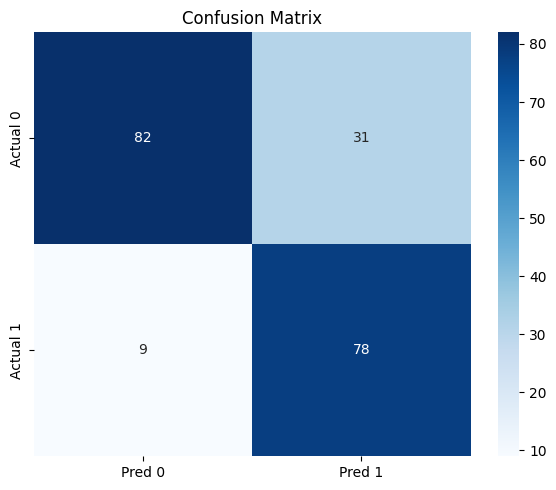

TP=78, TN=82, FP=31, FN=9
Accuracy  = 0.8000
Precision = 0.7156  (of all predicted positive, how many were correct?)
Recall    = 0.8966  (of all actual positive, how many did we catch?)
F1        = 0.7959


In [2]:
y_pred = lr.predict(X_te)
cm = confusion_matrix(y_te, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax.set_title('Confusion Matrix')
plt.tight_layout(); plt.show()

print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"Accuracy  = {(tp+tn)/(tp+tn+fp+fn):.4f}")
print(f"Precision = {tp/(tp+fp):.4f}  (of all predicted positive, how many were correct?)")
print(f"Recall    = {tp/(tp+fn):.4f}  (of all actual positive, how many did we catch?)")
print(f"F1        = {2*tp/(2*tp+fp+fn):.4f}")

---
## 2. Precision-Recall Trade-off via Threshold

### What this cell does:
Shows that changing the classification threshold moves the precision-recall trade-off. Default threshold is 0.5 but you can tune it based on business cost. Fraud detection often uses threshold=0.3 to maximize recall.

### Why Precision and Recall? Why the Trade-off?

**Precision** answers: *"When the model says positive, can I trust it?"*
```
Precision = TP / (TP + FP)

Out of everything flagged as fraud, how much was actually fraud?
High precision = few false alarms
```

**Recall** answers: *"Is the model finding all the positives?"*
```
Recall = TP / (TP + FN)

Out of all actual fraud cases, how many did we catch?
High recall = few missed cases
```

**Why they trade off — the threshold effect:**
```
Lower threshold (e.g. 0.3) → model flags MORE as positive
    → catches more real positives  → Recall ↑
    → also flags more negatives    → Precision ↓

Higher threshold (e.g. 0.7) → model flags FEWER as positive
    → only flags when very sure    → Precision ↑
    → misses more real positives   → Recall ↓
```

**How to choose:**
- FN is costly (cancer, fraud) → lower threshold → maximize **Recall**
- FP is costly (spam filter, drug recommendation) → raise threshold → maximize **Precision**

### Why F1 Score?

You need **one number** that captures both Precision and Recall — useful when comparing models or doing hyperparameter tuning.

**Why not just average them?**
```
Precision = 1.0,  Recall = 0.0
Simple average    = (1.0 + 0.0) / 2 = 0.50  ← looks okay
Harmonic mean F1  = 2×(1.0×0.0)/(1.0+0.0) = 0.00  ← correctly shows model is broken
```

The harmonic mean **punishes extreme imbalance** between precision and recall. A model that is great at one but terrible at the other gets a low F1.

```
Balanced model:   Precision=0.80, Recall=0.80  → F1 = 0.80
Imbalanced model: Precision=0.99, Recall=0.10  → F1 = 0.18  ← penalized correctly
```

**Use F1 when:** Classes are imbalanced, or both precision and recall matter equally.

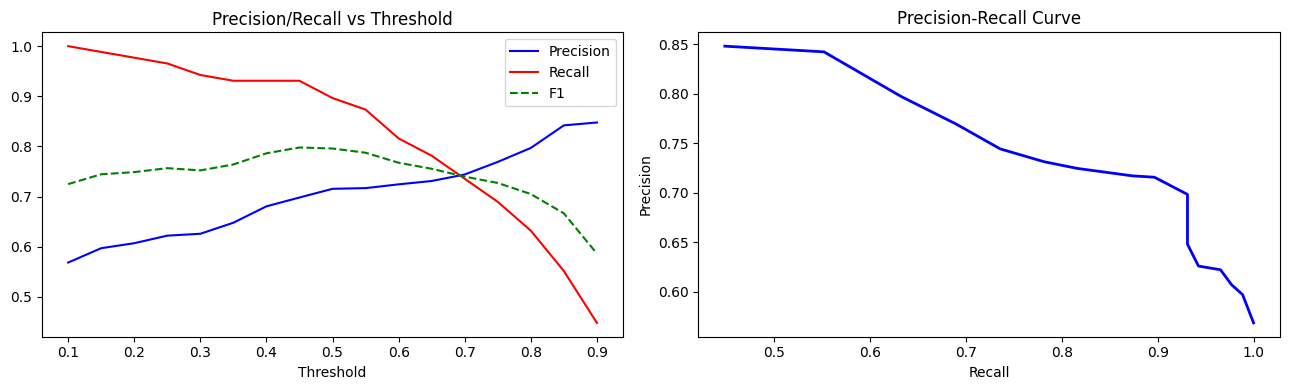

In [3]:
y_prob = lr.predict_proba(X_te)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_te, preds, zero_division=0))
    recalls.append(recall_score(y_te, preds, zero_division=0))
    f1s.append(f1_score(y_te, preds, zero_division=0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(thresholds, precisions, 'b-', label='Precision')
ax1.plot(thresholds, recalls, 'r-', label='Recall')
ax1.plot(thresholds, f1s, 'g--', label='F1')
ax1.set_xlabel('Threshold'); ax1.legend()
ax1.set_title('Precision/Recall vs Threshold')

ax2.plot(recalls, precisions, 'b-', lw=2)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
plt.tight_layout(); plt.show()

---
## 3. ROC-AUC & PR-AUC

### What this cell does:
ROC curve plots TPR vs FPR at all thresholds. AUC = area under curve (0.5=random, 1.0=perfect). PR-AUC is better for imbalanced data. Compares two models on the same axes so you can see which is better across the full threshold range.

### Why ROC-AUC?

A single threshold gives you one point on the precision-recall trade-off. **ROC-AUC evaluates the model across ALL thresholds at once** — it tells you how good the model is regardless of the operating threshold you choose.

**ROC Curve plots at every threshold:**
- X-axis: FPR = FP / (FP + TN) → how many negatives did we wrongly flag?
- Y-axis: TPR = Recall = TP / (TP + FN) → how many positives did we catch?

```
TPR
1.0 |         ........●   ← good model hugs top-left
    |      ...
    |    ./
    | ../
0.0 |●_______________
    0.0             1.0  FPR

Diagonal line = random guessing (AUC = 0.5)
```

**AUC Score:**
| AUC | Meaning |
|---|---|
| 1.0 | Perfect — model always separates classes |
| 0.9+ | Excellent |
| 0.8–0.9 | Good |
| 0.7–0.8 | Fair |
| 0.5 | Random guessing — useless |
| < 0.5 | Worse than random |

**Plain English:** AUC = probability that a randomly chosen positive example scores higher than a randomly chosen negative example.

**Limitation:** ROC-AUC uses TN in the FPR calculation. On heavily imbalanced data (e.g. 1% fraud), TN is huge and FPR stays artificially low — the curve looks great even for a bad model. Use **PR-AUC** instead.

### Why PR-AUC for Imbalanced Data?

**PR-AUC (Precision-Recall Area Under Curve)** plots Precision vs Recall at every threshold and measures the area under that curve.

**Why it's better than ROC-AUC for imbalanced data:**

ROC-AUC uses TN in its FPR formula. When negatives vastly outnumber positives, TN is huge → FPR stays small even when the model is bad → ROC curve looks good → AUC is misleadingly high.

PR-AUC **ignores TN entirely**. It only asks: "How well does the model find the rare positives?" — which is exactly the right question for imbalanced data.

```
Fraud dataset: 10,000 transactions, 100 are fraud (1%)

Lazy model — predicts everything as not-fraud:
  ROC-AUC ≈ 0.50  (correctly shows random-level)
  PR-AUC  ≈ 0.01  (correctly shows terrible — never finds fraud)

With a real imbalanced dataset, ROC-AUC can show 0.95+
while PR-AUC reveals the model is actually poor at finding the minority class.
```

**Rule of thumb:**
- Balanced classes (50/50) → use **ROC-AUC**
- Imbalanced classes (fraud, disease, rare events) → use **PR-AUC**

In [ ]:
#          Predicted Fraud   Predicted Normal
# Actual Fraud      0 (TP)         10 (FN)   ← missed ALL fraud
# Actual Normal     0 (FP)        990 (TN)

# Accuracy  = 99%   ← misleading
# Recall    = 0%    ← tells the truth: caught nothing
# Precision = 0%    ← tells the truth
# F1        = 0%    ← tells the truth


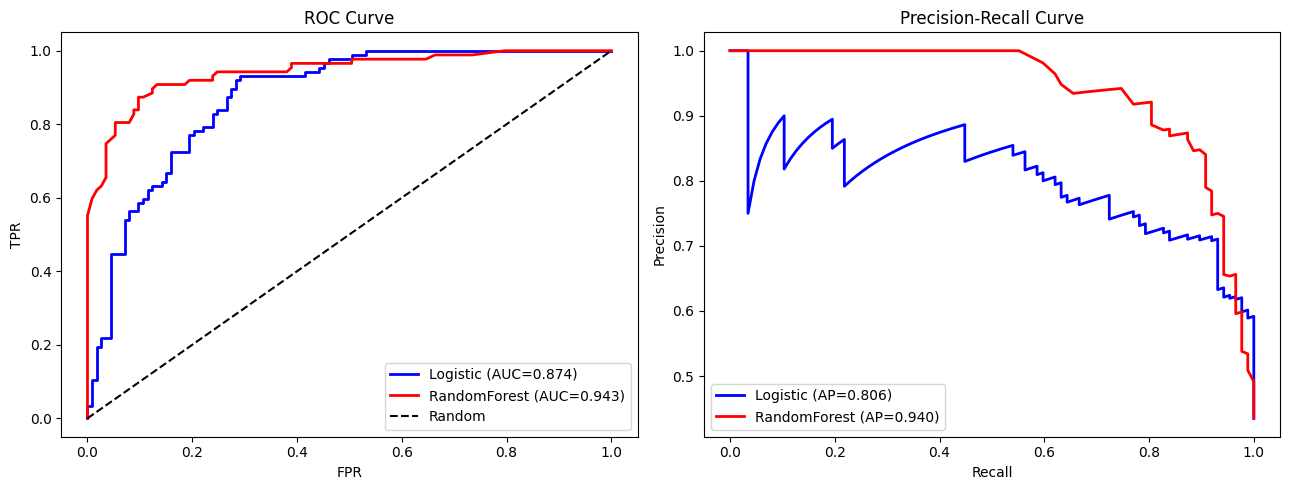

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model, name, color in [(lr, 'Logistic', 'blue'), (rf, 'RandomForest', 'red')]:
    probs = model.predict_proba(X_te)[:, 1]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_te, probs)
    auc = roc_auc_score(y_te, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
    
    # PR
    prec, rec, _ = precision_recall_curve(y_te, probs)
    ap = average_precision_score(y_te, probs)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')

axes[0].plot([0,1],[0,1],'k--',label='Random')
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
axes[0].legend()

axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
axes[1].legend()
plt.tight_layout(); plt.show()

---
## All Metrics — One Summary

```
Confusion Matrix:
         Predicted +   Predicted -
Actual +     80 (TP)      20 (FN)
Actual -     10 (FP)      90 (TN)

Accuracy  = (80+90) / 200        = 0.85
Precision = 80 / (80+10)         = 0.89   ← of what we flagged, how many were right?
Recall    = 80 / (80+20)         = 0.80   ← of all actual positives, how many we caught?
F1        = 2×(0.89×0.80)/(0.89+0.80) = 0.84
```

### When to use which metric

| Situation | Best metric |
|---|---|
| Balanced classes | Accuracy, F1, ROC-AUC |
| Imbalanced classes | F1, **PR-AUC** |
| Cost of FP is high (spam, false arrest) | **Precision** |
| Cost of FN is high (cancer, fraud) | **Recall** |
| Comparing models, balanced data | **ROC-AUC** |
| Comparing models, imbalanced data | **PR-AUC** |

### The Precision-Recall Trade-off in one line
> **Lower threshold → more recalls, less precision. Higher threshold → more precision, less recall. F1 balances both.**